# GDM Dataset – Data Preparation & Exploratory Analysis

**Bachelor's Thesis Project**

This notebook covers the full data-preparation and exploratory-analysis pipeline for a Gestational Diabetes Mellitus (GDM) dataset.  
The workflow is organised in five stages:

1. **Imports & Global Settings** – libraries and display options  
2. **Data Loading & Cleaning** – drop irrelevant columns, handle missing values, encode categorical variables  
3. **Exploratory Visualisations (Pie Charts)** – distribution of ethnicity, sex, delivery outcomes, labour methods  
4. **Ethnicity Merging & Feature Engineering** – remap ethnicities, drop redundant columns, finalise the *united* dataset  
5. **Bar Charts & Correlation Matrix** – normalised bar plots and Pearson correlation heatmap


## 1. Imports & Global Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Pandas display options ────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('future.no_silent_downcasting', True)

# ── Matplotlib / Seaborn global style ─────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
sns.set(style="whitegrid")

# ── Dataset paths ────────────────
DATA_PATH_RAW      = "../data/GDM Dataset.csv"
DATA_PATH_PREPARED = "../data/DataSet Prepared.csv"
DATA_PATH_UNITED   = "../data/DataSet Final.csv"

## 2. Data Loading & Cleaning

### 2.1 Load the raw dataset and drop irrelevant columns

The following columns are removed because they are either redundant, outside the scope of the analysis,
or have too many missing values to be useful:


In [2]:
data = pd.read_csv(DATA_PATH_RAW)

# Columns to drop – irrelevant or out-of-scope for this analysis
COLS_TO_DROP = [
    'Index of Multiple Deprivation Rank', 'Obese?', 'GlucoseToleranceTest',
    'FolicAcidDose', 'SystolicBloodPressureCuff', 'Diastolic Blood Pressure',
    'VitaminDlevelblood', 'O_Thyroidfunctionblood',
    'Contraction frequency prior to delivery', 'PrimaryIndicationforCaesarean',
    'Category Caesarean Section', 'Perineal care', 'EstimatedTotalBloodLoss',
    'Gestation', 'Gestation at booking (Weeks)', 'BabyBirthWeight',
    'Presence of meconium', 'LOS mother after delivery', 'Still_Birth',
    'TotalApgarScoreat1minutes', 'APGAR_Score_5', 'TotalApgarScoreat10minutes',
    'Maternity_Month'
]
data = data.drop(columns=COLS_TO_DROP)

print(f"Dataset shape after column drop: {data.shape}")
data.head()

Dataset shape after column drop: (23490, 25)


,UID,IMD Decile,AgeAtStartOfSpell,WeightMeasured,Height,Body Mass Index at Booking,Ethnicity,Risk Factors,AntenatalMedicalFactors,PreviousObstetricHistory,Parity,Gravida,Glucoselevelblood,Glucoselevel0minblood,Glucoselevel120minblood,GestationalDiabetes,Delivery_Outcome,OnsetofLabourMethod,Severely Premature?,Gestation (Days),No_Of_previous_Csections,BW Centile,Shoulder Dystocia,SCBU admission (Yes/NO),Sex
0,1,7,30,101.008592,178.0,31.88,GBR,NaN,Mental health,NaN,0,1.0,NaN,4.6,5.5,No,Spontaneous Vertex,Spontaneous,No,266,0,44.8,No,No,Female
1,2,6,29,91.014089,173.0,30.41,OTH,NaN,NaN,NaN,0,1.0,NaN,4.3,7,No,"Ventouse, Vacuum Extraction",Medical Induction,No,294,0,19.7,No,No,Male
2,3,2,22,65.395008,168.0,23.17,GBR,NaN,NaN,NaN,0,1.0,NaN,NaN,NaN,No,"Ventouse, Vacuum Extraction",Medical Induction,No,273,0,75.8,No,No,Female
3,4,3,31,49.997000,170.0,17.30,WEU,NaN,NaN,NaN,0,1.0,NaN,NaN,NaN,No,Spontaneous Vertex,Spontaneous,No,273,0,79.0,No,No,Female
4,5,5,24,54.300537,171.0,18.57,GBR,NaN,NaN,NaN,0,1.0,NaN,NaN,NaN,No,Spontaneous Vertex,Spontaneous,No,273,0,66.1,No,No,Female


### 2.2 Inspect categorical columns and missing values

In [3]:
# ── Ethnicity ─────────────────────────────────────────────────────────────────
print("Ethnicity unique values:", list(data['Ethnicity'].unique()))
print("Number of ethnicity types:", data['Ethnicity'].nunique(), "\n")

# ── Previous Obstetric History ────────────────────────────────────────────────
print("Number of Obstetric history types:", data['PreviousObstetricHistory'].nunique())
print("NaNs in PreviousObstetricHistory:", data['PreviousObstetricHistory'].isna().sum(), "\n")

# ── Delivery Outcomes ─────────────────────────────────────────────────────────
print("Number of delivery outcome types:", data['Delivery_Outcome'].nunique())
print("NaNs in Delivery_Outcome:", data['Delivery_Outcome'].isna().sum(), "\n")
print(data['Delivery_Outcome'].value_counts(), "\n")

# ── Onset of Labour Method ────────────────────────────────────────────────────
print("Number of Labour method types:", data['OnsetofLabourMethod'].nunique())
print("NaNs in OnsetofLabourMethod:", data['OnsetofLabourMethod'].isna().sum())

# Drop features with too many unique categories
data.drop(columns='PreviousObstetricHistory', inplace=True, errors='ignore')
data.drop(columns='Delivery_Outcome', inplace=True, errors='ignore')

Ethnicity unique values: ['GBR', 'OTH', 'WEU', 'ASE', 'CAR', 'CAE', 'MEA', 'NAF', 'IND', 'IRL', 'AFE', 'PAK', 'BGD']
Number of ethnicity types: 13 

Number of Obstetric history types: 140
NaNs in PreviousObstetricHistory: 21151 

Number of delivery outcome types: 12
NaNs in Delivery_Outcome: 0 

Delivery_Outcome
Spontaneous Vertex             12639
Elective caesarean section      3251
Emergency caesarean section     3228
Ventouse, Vacuum Extraction     1775
Low Forceps, not Breech         1271
Emergency Caesarean Section      784
Ventouse, Rotational             220
Other Forceps, not Breech        131
Breech                            80
Other method of delivery          58
Spontaneous Other Cephalic        37
Breech Extraction                 16
Name: count, dtype: int64 

Number of Labour method types: 5
NaNs in OnsetofLabourMethod: 73


### 2.3 Encode the target variable – Gestational Diabetes

In [4]:
# Count positive cases before encoding
n_gdm = (data['GestationalDiabetes'] == 'Yes').sum()
print(f"Number of women diagnosed with GDM: {n_gdm}")

# Binary encoding: Yes → 1, No → 0
data['GestationalDiabetes'] = data['GestationalDiabetes'].replace({'Yes': 1, 'No': 0})
print("GestationalDiabetes value counts after encoding:\n", data['GestationalDiabetes'].value_counts())

Number of women diagnosed with GDM: 1854
GestationalDiabetes value counts after encoding:
 GestationalDiabetes
0    21636
1     1854
Name: count, dtype: int64


### 2.4 Merge glucose-level columns into a single maximum value

In [5]:
# Convert all three glucose columns to numeric (coerce errors → NaN)
glucose_cols = ['Glucoselevelblood', 'Glucoselevel0minblood', 'Glucoselevel120minblood']
data[glucose_cols] = data[glucose_cols].apply(pd.to_numeric, errors='coerce')

# Remember the insertion position so we keep column order consistent
col_index_gluc = data.columns.get_loc('Glucoselevelblood')

# Take the row-wise maximum across the three glucose measurements
data['Max_Glucose_Value'] = data[glucose_cols].max(axis=1, skipna=True)

# Drop original columns and re-insert the aggregated one at the same position
data.drop(columns=glucose_cols, inplace=True)
data.insert(col_index_gluc, 'Max_Glucose_Value', data.pop('Max_Glucose_Value'))

print(f"NaNs in Max_Glucose_Value: {data['Max_Glucose_Value'].isna().sum()}")

NaNs in Max_Glucose_Value: 5440


### 2.5 Merge Risk Factors columns and encode as binary

In [6]:
# Columns 'Risk Factors' and 'AntenatalMedicalFactors' are complementary –
# fill NaNs in the first with values from the second, then keep a single column.
index_col_risk = data.columns.get_loc('Risk Factors')
data['RiskFactorsMerged'] = data['Risk Factors'].fillna(data['AntenatalMedicalFactors'])
data.drop(columns=['Risk Factors', 'AntenatalMedicalFactors'], inplace=True)
data.insert(index_col_risk, 'RiskFactorsMerged', data.pop('RiskFactorsMerged'))

print("Number of risk factor types:", data['RiskFactorsMerged'].nunique())
print("NaNs in RiskFactorsMerged:", data['RiskFactorsMerged'].isna().sum())

# Binary encoding: any non-null entry → 1 (risk factor present), NaN → 0
data['RiskFactorsMerged'] = data['RiskFactorsMerged'].apply(lambda x: 0 if pd.isna(x) else 1)
print("\nRiskFactorsMerged value counts:\n", data['RiskFactorsMerged'].value_counts())

Number of risk factor types: 373
NaNs in RiskFactorsMerged: 15250

RiskFactorsMerged value counts:
 RiskFactorsMerged
0    15250
1     8240
Name: count, dtype: int64


### 2.6 Encode remaining binary columns

In [7]:
# Severely Premature: Yes → 1, No → 0
data['Severely Premature?'] = data['Severely Premature?'].replace({'Yes': 1, 'No': 0})
print("Severely Premature value counts:\n", data['Severely Premature?'].value_counts(), "\n")

# Previous C-sections: any number > 0 → 1 (has had a C-section before)
data['Prev_CSections'] = data['No_Of_previous_Csections'].apply(lambda x: 1 if x != 0 else 0)

# SCBU admission: Yes → 1, No → 0
data['SCBU admission'] = data['SCBU admission (Yes/NO)'].replace({'Yes': 1, 'No': 0})
data.drop(columns=['SCBU admission (Yes/NO)'], inplace=True)
print("SCBU admission value counts:\n", data['SCBU admission'].value_counts(), "\n")

# Shoulder Dystocia: Yes → 1, No → 0
data['Shoulder Dystocia'] = data['Shoulder Dystocia'].replace({'Yes': 1, 'No': 0})

# Sex: Male → 1, Female → 0
data['Sex'] = data['Sex'].replace({'Male': 1, 'Female': 0})

print("Final dataset shape:", data.shape)

Severely Premature value counts:
 Severely Premature?
0    23216
1      274
Name: count, dtype: int64 

SCBU admission value counts:
 SCBU admission
0    22195
1     1295
Name: count, dtype: int64 

Final dataset shape: (23490, 21)


### 2.7 Save the prepared dataset

In [8]:
data.to_csv(DATA_PATH_PREPARED, index=False)
print(f"Prepared dataset saved to: {DATA_PATH_PREPARED}")

Prepared dataset saved to: ../data/DataSet Prepared.csv


## 3. Exploratory Visualisations – Pie Charts

Overview of the main categorical distributions in the **raw** dataset.


In [9]:
# Reload raw data for plotting (before any encoding)
data_raw = pd.read_csv(DATA_PATH_RAW)
data_raw = data_raw.drop(columns=COLS_TO_DROP)

### 3.1 Ethnicity distribution

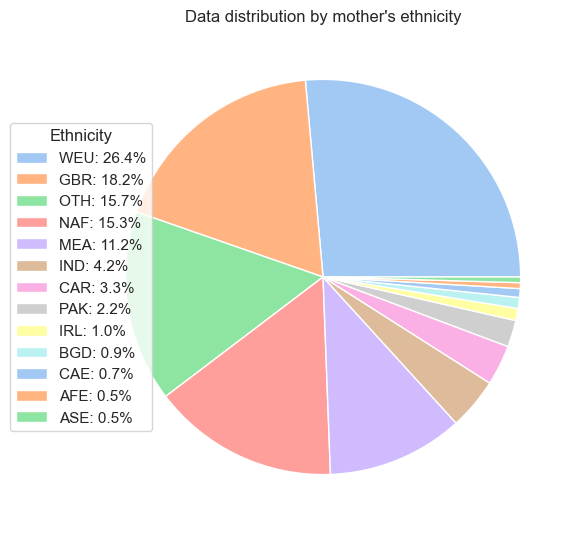

In [10]:
etnie = data_raw['Ethnicity'].value_counts()
percentuali_etnie = etnie / etnie.sum() * 100
labels_etnie = [f"{cat}: {perc:.1f}%" for cat, perc in zip(etnie.index, percentuali_etnie)]

plt.figure(figsize=(6, 6))
plt.pie(etnie, labels=None, colors=sns.color_palette("pastel"))
plt.legend(labels_etnie, title="Ethnicity", loc="center right", bbox_to_anchor=(0.17, 0.5))
plt.title("Data distribution by mother's ethnicity")
plt.tight_layout()
plt.show()

### 3.2 Baby sex distribution

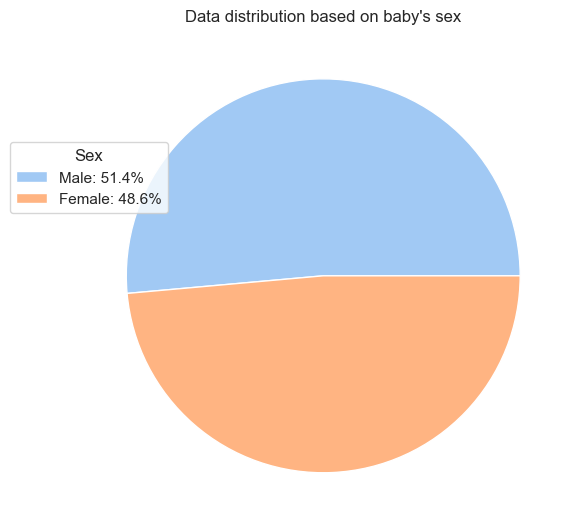

In [11]:
sex = data_raw['Sex'].value_counts()
percentuali_sex = sex / sex.sum() * 100
labels_sex = [f"{cat}: {perc:.1f}%" for cat, perc in zip(sex.index, percentuali_sex)]

plt.figure(figsize=(6, 6))
plt.pie(sex, labels=None, colors=sns.color_palette("pastel"))
plt.legend(labels_sex, title="Sex", loc="center right", bbox_to_anchor=(0.2, 0.7))
plt.title("Data distribution based on baby's sex")
plt.tight_layout()
plt.show()

### 3.3 Delivery outcomes distribution

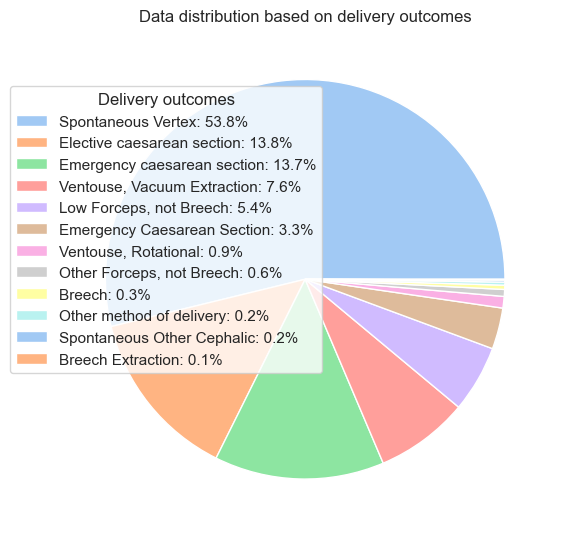

In [12]:
delivery = data_raw['Delivery_Outcome'].value_counts()
percentuali_delivery = delivery / delivery.sum() * 100
labels_delivery = [f"{cat}: {perc:.1f}%" for cat, perc in zip(delivery.index, percentuali_delivery)]

plt.figure(figsize=(6, 6))
plt.pie(delivery, labels=None, colors=sns.color_palette("pastel"))
plt.legend(labels_delivery, title="Delivery outcomes", loc="center right", bbox_to_anchor=(0.55, 0.6))
plt.title("Data distribution based on delivery outcomes")
plt.tight_layout()
plt.show()

### 3.4 Onset of labour method distribution

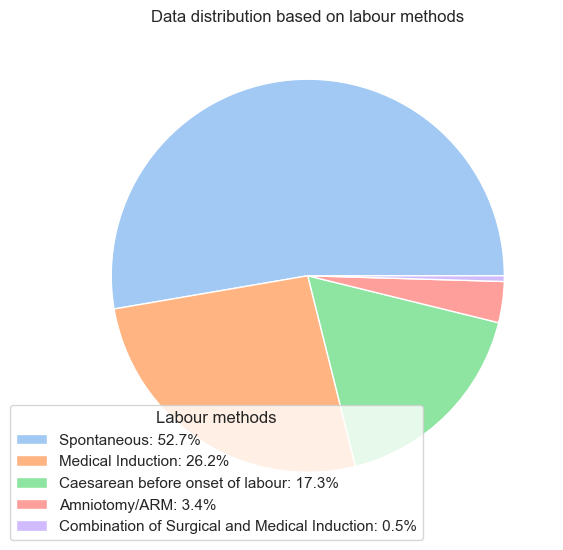

In [13]:
labour = data_raw['OnsetofLabourMethod'].value_counts()
percentuali_labour = labour / labour.sum() * 100
labels_labour = [f"{cat}: {perc:.1f}%" for cat, perc in zip(labour.index, percentuali_labour)]

plt.figure(figsize=(6, 6))
plt.pie(labour, labels=None, colors=sns.color_palette("pastel"))
plt.legend(labels_labour, title="Labour methods", loc="center right", bbox_to_anchor=(0.75, 0.1))
plt.title("Data distribution based on labour methods")
plt.tight_layout()
plt.show()

## 4. Ethnicity Merging & Feature Engineering

The original dataset contains 13 fine-grained ethnicity codes.  
To reduce dimensionality and improve statistical power, they are merged into **5 macro-groups**:

| Code(s) | Macro-group | Description |
|---------|-------------|-------------|
| AFE, NAF, MEA | AFR | Africa & Middle East |
| BGD, IND, PAK, ASE | ASIA | South & East Asia |
| GBR, WEU, IRL | EUR | Europe |
| CAE, CAR | CARIB | Caribbean |
| OTH | OTH | Other |


In [14]:
# Load the prepared dataset
data = pd.read_csv(DATA_PATH_PREPARED)

# Mapping from original codes to macro-groups
ethnicity_mapping = {
    'AFE': 'AFR',   # Africa & Middle East
    'NAF': 'AFR',
    'MEA': 'AFR',
    'BGD': 'ASIA',  # South & East Asia
    'IND': 'ASIA',
    'PAK': 'ASIA',
    'ASE': 'ASIA',
    'GBR': 'EUR',   # Europe
    'WEU': 'EUR',
    'IRL': 'EUR',
    'CAE': 'CARIB', # Caribbean
    'CAR': 'CARIB',
    'OTH': 'OTH',   # Other
}

data['Ethnicity'] = data['Ethnicity'].map(ethnicity_mapping)
print("Ethnicity distribution after merging:\n", data['Ethnicity'].value_counts())

Ethnicity distribution after merging:
 Ethnicity
EUR      10722
AFR       6319
OTH       3681
ASIA      1826
CARIB      942
Name: count, dtype: int64


### 4.1 Pie chart – merged ethnicity groups

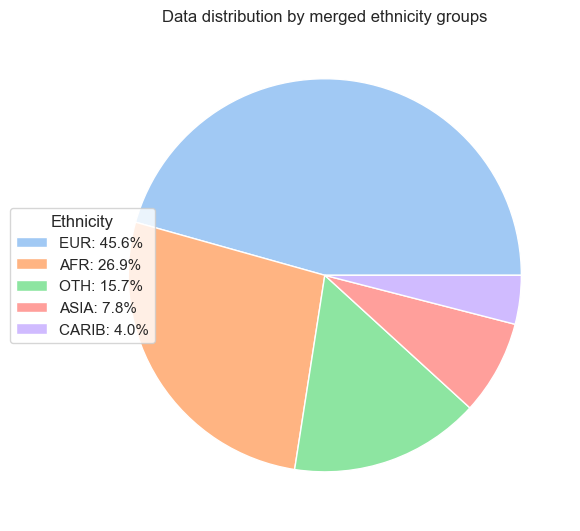

In [15]:
etnie = data['Ethnicity'].value_counts()
percentuali_etnie = etnie / etnie.sum() * 100
labels_etnie = [f"{cat}: {perc:.1f}%" for cat, perc in zip(etnie.index, percentuali_etnie)]

plt.figure(figsize=(6, 6))
plt.pie(etnie, labels=None, colors=sns.color_palette("pastel"))
plt.legend(labels_etnie, title="Ethnicity", loc="center right", bbox_to_anchor=(0.17, 0.5))
plt.title("Data distribution by merged ethnicity groups")
plt.tight_layout()
plt.show()

### 4.2 Drop columns with too many categories or too many NaNs
Drop rows with NaN in `OnsetofLabourMethod` (73 rows) and `Gravida` (11 rows) 


In [16]:

data.dropna(subset=['OnsetofLabourMethod', 'Gravida'], inplace=True)
print(f"NaNs in OnsetofLabourMethod after drop: {data['OnsetofLabourMethod'].isna().sum()}")
print(f"Dataset shape: {data.shape}")

NaNs in OnsetofLabourMethod after drop: 0
Dataset shape: (23406, 21)


### 4.3 Drop highly-correlated and identifier columns

In [17]:
# WeightMeasured is highly correlated with BMI (already present) → drop
# UID is a row identifier with no predictive value → drop
# No_Of_previous_Csections is already encoded as Prev_CSections → drop
data.drop(columns=['WeightMeasured', 'UID', 'No_Of_previous_Csections'], inplace=True)

print(f"Final dataset shape: {data.shape}")

Final dataset shape: (23406, 18)


### 4.4 Final NaN check and save the united dataset

In [18]:
print("Remaining NaNs per column:")
print(data.isna().sum())

data.to_csv(DATA_PATH_UNITED, index=False)
print(f"\nUnited dataset saved to: {DATA_PATH_UNITED}")

Remaining NaNs per column:
IMD Decile                       0
AgeAtStartOfSpell                0
Height                           0
Body Mass Index at Booking       0
Ethnicity                        0
RiskFactorsMerged                0
Parity                           0
Gravida                          0
Max_Glucose_Value             5428
GestationalDiabetes              0
OnsetofLabourMethod              0
Severely Premature?              0
Gestation (Days)                 0
BW Centile                       0
Shoulder Dystocia                0
Sex                              0
Prev_CSections                   0
SCBU admission                   0
dtype: int64

United dataset saved to: ../data/DataSet Final.csv


## 5. Bar Charts – Normalised Relationships

All bar charts below show **normalised** rates: the count of positive outcomes divided  
by the total population in each group, so that group size does not distort the comparison.


### 5.1 SCBU admission rate by maternal BMI category

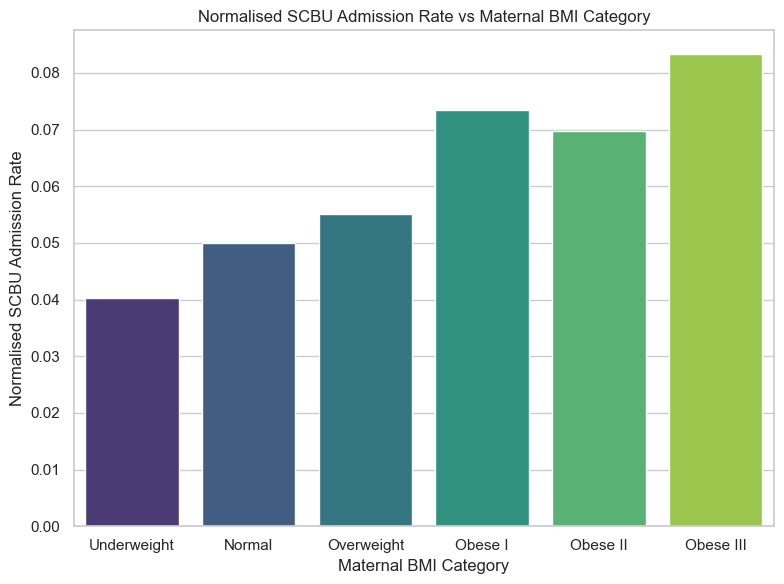

In [19]:
data = pd.read_csv(DATA_PATH_PREPARED)

# Bin BMI into standard clinical categories
bins   = [0, 18.5, 25, 30, 35, 40, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II", "Obese III"]
data["BMI Category"] = pd.cut(data["Body Mass Index at Booking"], bins=bins, labels=labels, right=False)

# Normalise: SCBU admissions / total mothers in each BMI category
population_per_bmi = data["BMI Category"].value_counts()
scbu_per_bmi       = data.groupby("BMI Category")["SCBU admission"].sum()
df_bmi_scbu = (scbu_per_bmi / population_per_bmi).reset_index()
df_bmi_scbu.columns = ["BMI Category", "SCBU_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="BMI Category", y="SCBU_rate", data=df_bmi_scbu, palette="viridis")
plt.xlabel("Maternal BMI Category")
plt.ylabel("Normalised SCBU Admission Rate")
plt.title("Normalised SCBU Admission Rate vs Maternal BMI Category")
plt.tight_layout()
plt.show()

### 5.2 GDM diagnosis rate by ethnicity (prepared dataset)

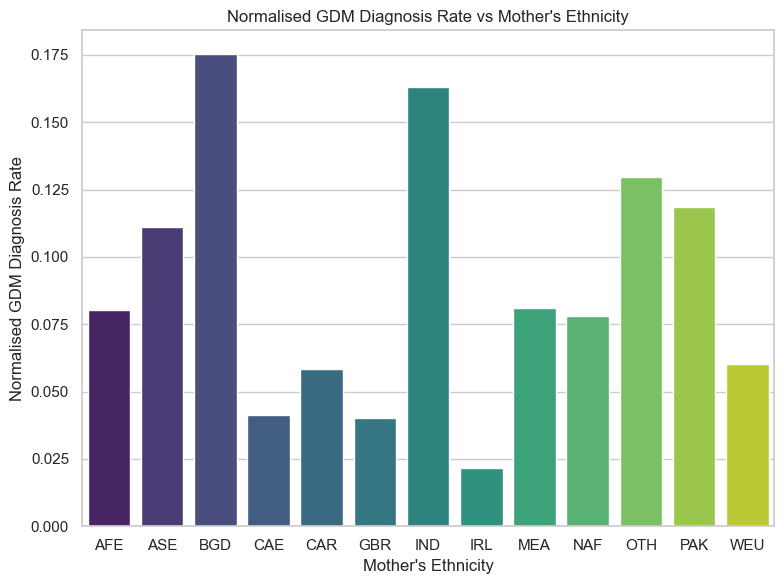

In [20]:
population_per_ethnicity = data["Ethnicity"].value_counts()
gdm_per_ethnicity        = data.groupby("Ethnicity")["GestationalDiabetes"].sum()
df_ethnicity_gdm = (gdm_per_ethnicity / population_per_ethnicity).reset_index()
df_ethnicity_gdm.columns = ["Ethnicity", "GDM_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="Ethnicity", y="GDM_rate", data=df_ethnicity_gdm, palette="viridis")
plt.xlabel("Mother's Ethnicity")
plt.ylabel("Normalised GDM Diagnosis Rate")
plt.title("Normalised GDM Diagnosis Rate vs Mother's Ethnicity")
plt.tight_layout()
plt.show()

### 5.3 SCBU admission rate by ethnicity (prepared dataset)

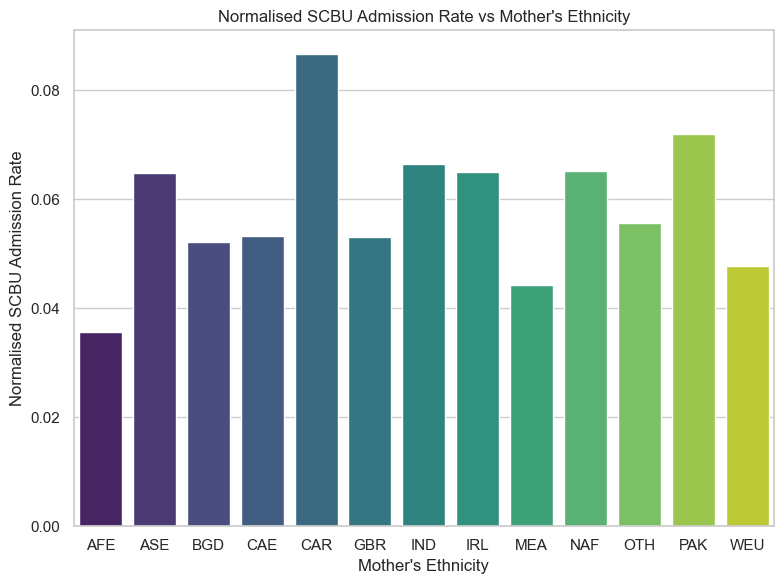

In [21]:
scbu_per_ethnicity = data.groupby("Ethnicity")["SCBU admission"].sum()
df_ethnicity_scbu = (scbu_per_ethnicity / population_per_ethnicity).reset_index()
df_ethnicity_scbu.columns = ["Ethnicity", "SCBU_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="Ethnicity", y="SCBU_rate", data=df_ethnicity_scbu, palette="viridis")
plt.xlabel("Mother's Ethnicity")
plt.ylabel("Normalised SCBU Admission Rate")
plt.title("Normalised SCBU Admission Rate vs Mother's Ethnicity")
plt.tight_layout()
plt.show()

### 5.4 SCBU admission rate by baby's sex

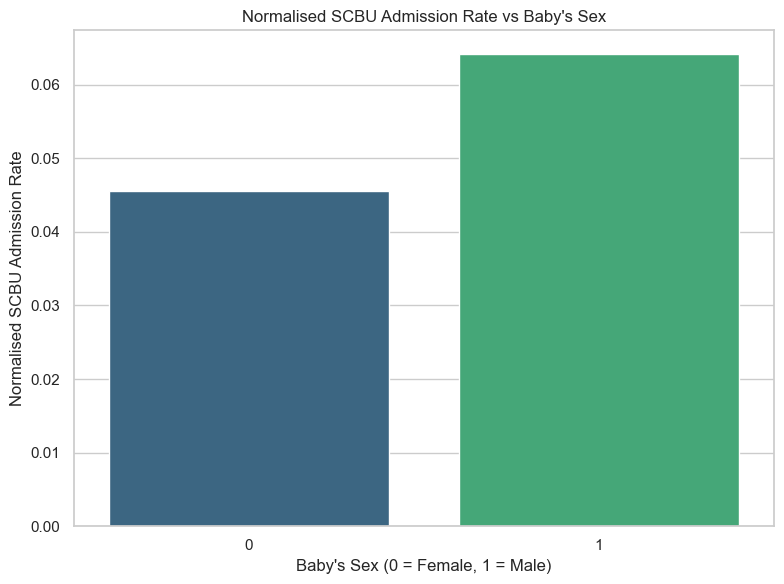

In [22]:
babies_per_sex   = data["Sex"].value_counts()
scbu_per_sex     = data.groupby("Sex")["SCBU admission"].sum()
df_sex_scbu      = (scbu_per_sex / babies_per_sex).reset_index()
df_sex_scbu.columns = ["Sex", "SCBU_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="Sex", y="SCBU_rate", data=df_sex_scbu, palette="viridis")
plt.xlabel("Baby's Sex (0 = Female, 1 = Male)")
plt.ylabel("Normalised SCBU Admission Rate")
plt.title("Normalised SCBU Admission Rate vs Baby's Sex")
plt.tight_layout()
plt.show()

### 5.5 SCBU admission rate by maternal GDM diagnosis

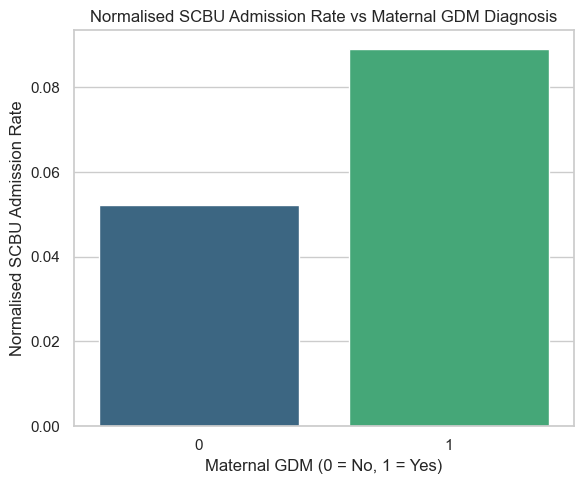

In [23]:
mothers_per_gdm  = data["GestationalDiabetes"].value_counts()
scbu_per_gdm     = data.groupby("GestationalDiabetes")["SCBU admission"].sum()
df_gdm_scbu      = (scbu_per_gdm / mothers_per_gdm).reset_index()
df_gdm_scbu.columns = ["GDM", "SCBU_rate"]

plt.figure(figsize=(6, 5))
sns.barplot(x="GDM", y="SCBU_rate", data=df_gdm_scbu, palette="viridis")
plt.xlabel("Maternal GDM (0 = No, 1 = Yes)")
plt.ylabel("Normalised SCBU Admission Rate")
plt.title("Normalised SCBU Admission Rate vs Maternal GDM Diagnosis")
plt.tight_layout()
plt.show()

### 5.6 Bar charts on the united (merged ethnicity) dataset

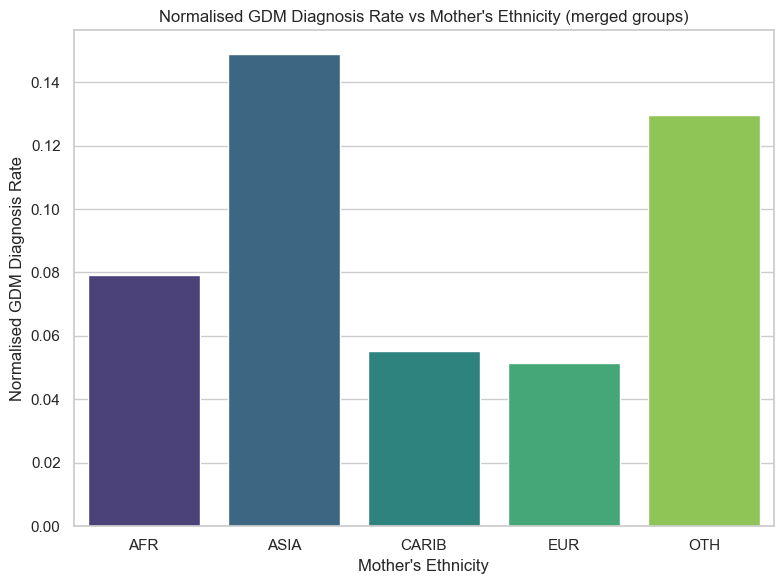

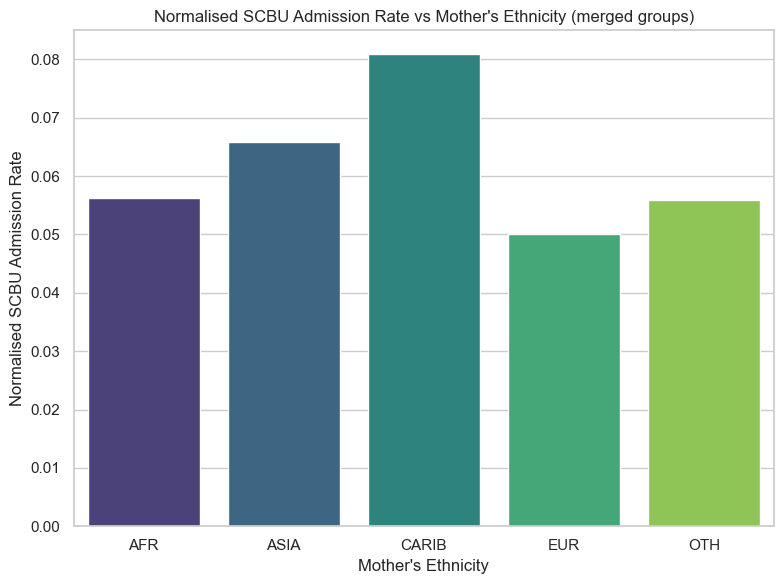

In [24]:
data_united = pd.read_csv(DATA_PATH_UNITED)

# GDM rate by ethnicity
pop_eth   = data_united["Ethnicity"].value_counts()
gdm_eth   = data_united.groupby("Ethnicity")["GestationalDiabetes"].sum()
df_e_gdm  = (gdm_eth / pop_eth).reset_index()
df_e_gdm.columns = ["Ethnicity", "GDM_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="Ethnicity", y="GDM_rate", data=df_e_gdm, palette="viridis")
plt.xlabel("Mother's Ethnicity")
plt.ylabel("Normalised GDM Diagnosis Rate")
plt.title("Normalised GDM Diagnosis Rate vs Mother's Ethnicity (merged groups)")
plt.tight_layout()
plt.show()

# SCBU admission rate by ethnicity
scbu_eth  = data_united.groupby("Ethnicity")["SCBU admission"].sum()
df_e_scbu = (scbu_eth / pop_eth).reset_index()
df_e_scbu.columns = ["Ethnicity", "SCBU_rate"]

plt.figure(figsize=(8, 6))
sns.barplot(x="Ethnicity", y="SCBU_rate", data=df_e_scbu, palette="viridis")
plt.xlabel("Mother's Ethnicity")
plt.ylabel("Normalised SCBU Admission Rate")
plt.title("Normalised SCBU Admission Rate vs Mother's Ethnicity (merged groups)")
plt.tight_layout()
plt.show()

## 6. Pearson Correlation Matrix

Computed on the **united dataset** (after dropping non-numeric columns).  
The heatmap highlights linear relationships between all features and helps identify  
multicollinearity (e.g. `WeightMeasured` vs `BMI`, which led to removing the former).


In [25]:
data_united = pd.read_csv(DATA_PATH_UNITED)

# Drop categorical string columns that cannot be included in a numeric correlation
data_corr = data_united.drop(columns=['Ethnicity', 'OnsetofLabourMethod'], errors='ignore')

correlation_matrix = data_corr.corr(method='pearson')

# Print correlations with the target variable
print("Pearson correlation with SCBU admission:")
print(correlation_matrix[['SCBU admission']].sort_values('SCBU admission', ascending=False))

Pearson correlation with SCBU admission:
                            SCBU admission
SCBU admission                    1.000000
Severely Premature?               0.350263
Max_Glucose_Value                 0.067975
RiskFactorsMerged                 0.048579
GestationalDiabetes               0.042432
Sex                               0.040763
Body Mass Index at Booking        0.040423
Prev_CSections                    0.026771
AgeAtStartOfSpell                 0.019200
Shoulder Dystocia                 0.015837
Parity                            0.002704
Gravida                          -0.001430
IMD Decile                       -0.008757
Height                           -0.026276
BW Centile                       -0.030557
Gestation (Days)                 -0.388812


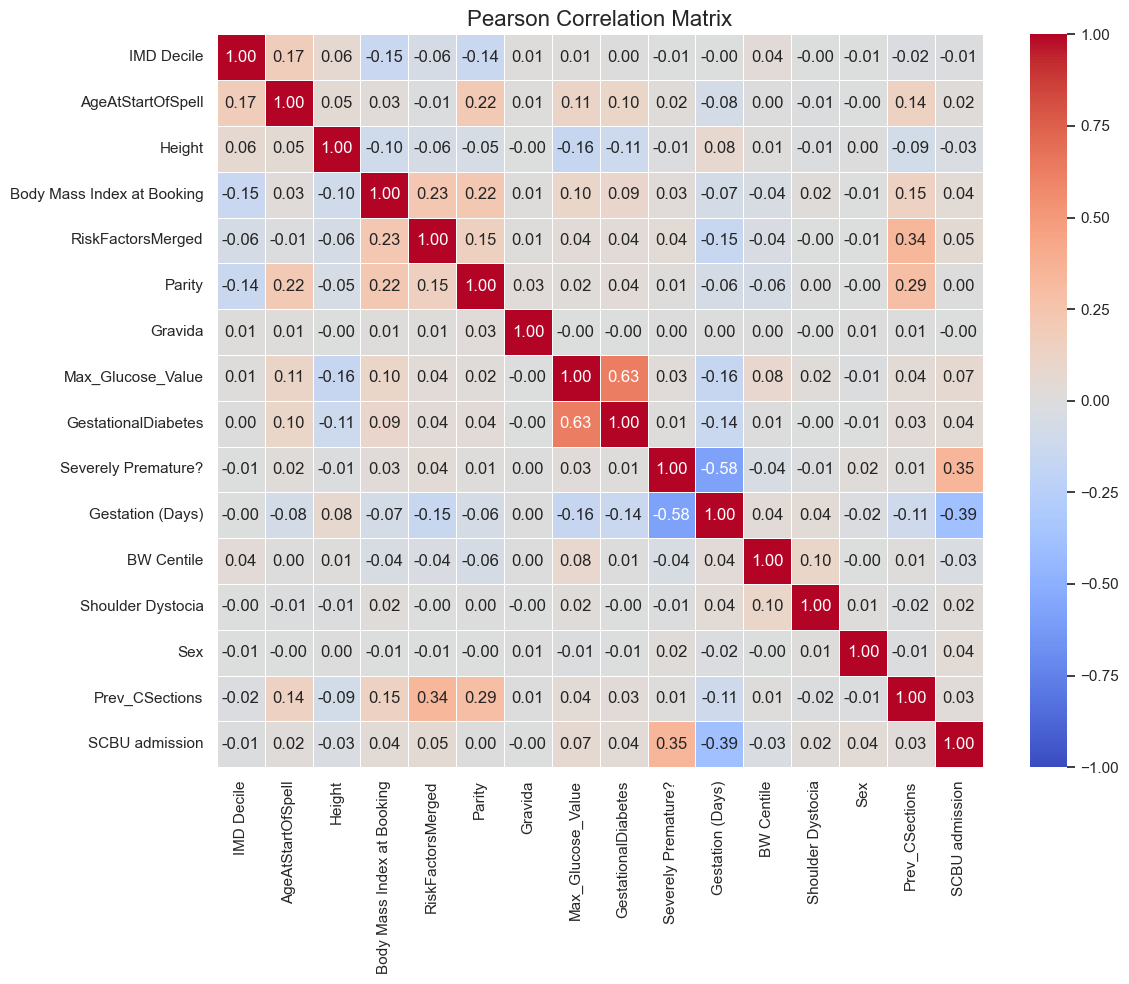

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f",
)
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### 6.1 Drop highly correlated features
- Max_Glucose_Value feature is highly correlated to GDM.
- Severely Premature is highly correlated (inverse correlation) with Gestation (Days)

In [27]:
data = pd.read_csv(DATA_PATH_UNITED)
data.drop(columns=['Max_Glucose_Value', 'Severely Premature?'], inplace=True, errors='ignore')

data.to_csv(DATA_PATH_UNITED, index=False)
print(f"\nUnited dataset saved to: {DATA_PATH_UNITED}")


United dataset saved to: ../data/DataSet Final.csv


### 6.2 Check again the correlation

In [28]:
data_united = pd.read_csv(DATA_PATH_UNITED)

# Drop categorical string columns that cannot be included in a numeric correlation
data_corr = data_united.drop(columns=['Ethnicity', 'OnsetofLabourMethod'], errors='ignore')

correlation_matrix = data_corr.corr(method='pearson')

# Print correlations with the target variable
print("Pearson correlation with SCBU admission:")
print(correlation_matrix[['SCBU admission']].sort_values('SCBU admission', ascending=False))

Pearson correlation with SCBU admission:
                            SCBU admission
SCBU admission                    1.000000
RiskFactorsMerged                 0.048579
GestationalDiabetes               0.042432
Sex                               0.040763
Body Mass Index at Booking        0.040423
Prev_CSections                    0.026771
AgeAtStartOfSpell                 0.019200
Shoulder Dystocia                 0.015837
Parity                            0.002704
Gravida                          -0.001430
IMD Decile                       -0.008757
Height                           -0.026276
BW Centile                       -0.030557
Gestation (Days)                 -0.388812


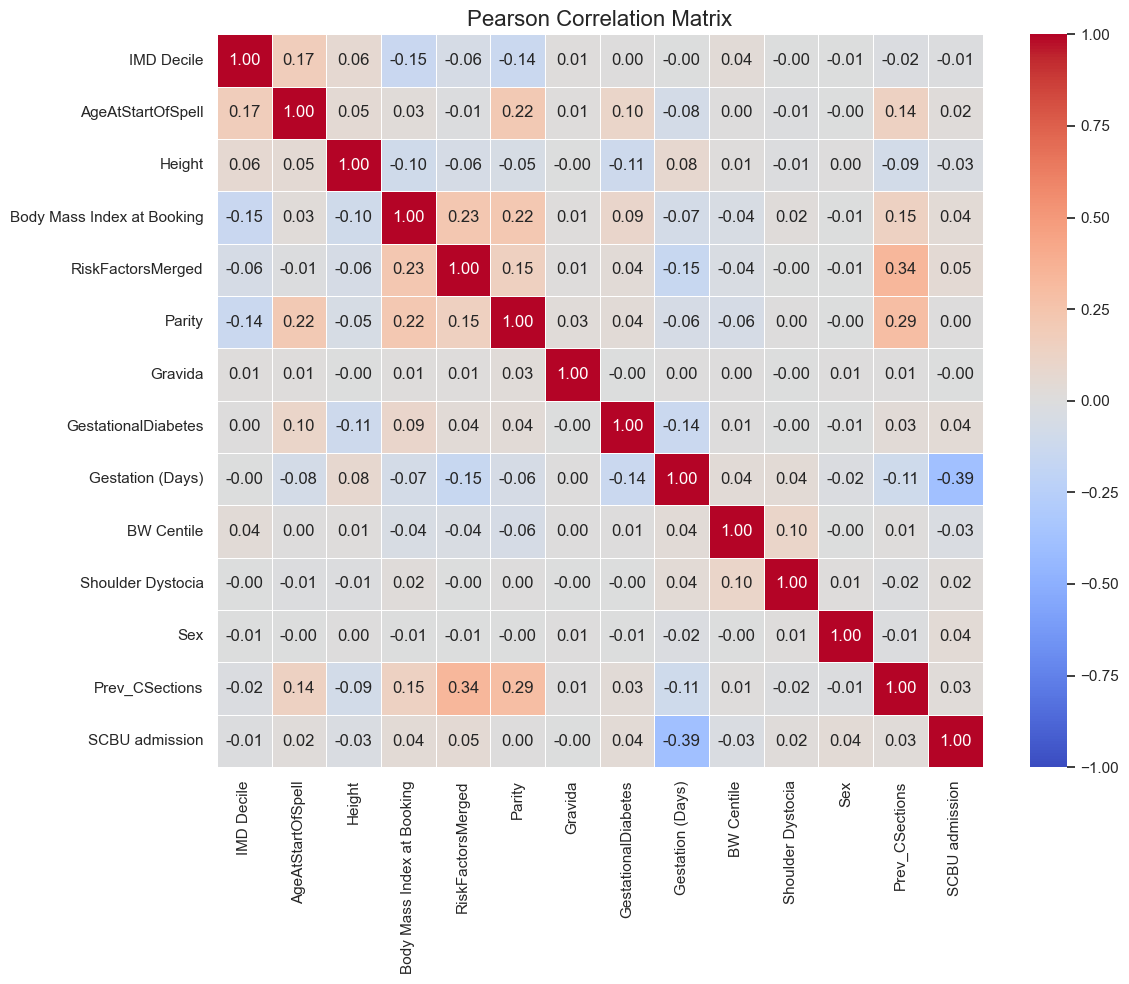

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f",
)
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()